# 07 · Fusion and Association with Attributes / Classification
**Companion to the lecture:** *Fusion and Association with Attributes/Classification* — Yaakov Bar-Shalom.

> ⚠️ The slides for this lecture are **not** in the PDF. This notebook is based on the canonical literature and on 
> Blasch's reference in the introduction to 'Object level — Bayes versus Dempster-Shafer'.

So far we have dealt with the **kinematic** state (position/velocity). Attributes — such as the **target class** (ID) — 
add another dimension to fusion: they improve both **association** (you must not assign a 'truck' measurement to an 
'aircraft' track) and **identification**.

## A. Bayesian classification and sequential fusion
Given a prior over classes $P(c)$ and the sensor's 'confusion matrix' $P(z\mid c)$, each measurement updates the 
posterior via Bayes' rule, thereby **accumulating confidence** over time/sensors:
$$P(c\mid z_{1:k}) \propto P(z_k\mid c)\,P(c\mid z_{1:k-1})$$

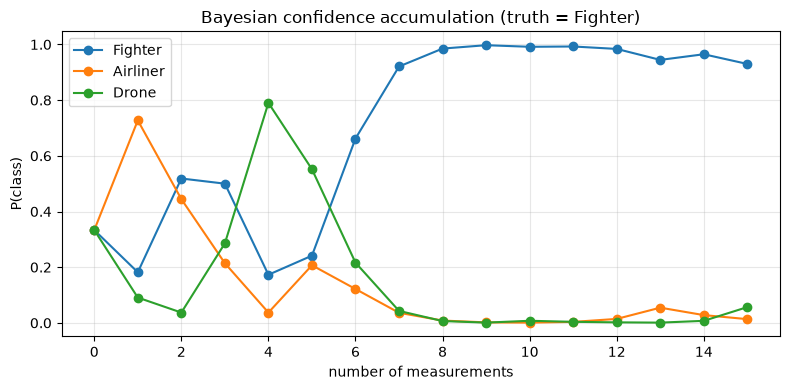

final posterior: {'Fighter': np.float64(0.93), 'Airliner': np.float64(0.013), 'Drone': np.float64(0.057)}


In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(9)
classes = ['Fighter','Airliner','Drone']
# confusion matrix: row = true class, column = sensor report
C = np.array([[0.70,0.20,0.10],
              [0.15,0.80,0.05],
              [0.10,0.10,0.80]])

def bayes_fuse(prior, reports, C):
    p = prior.copy(); hist=[p.copy()]
    for r in reports:
        p = C[:,r]*p; p/=p.sum(); hist.append(p.copy())
    return p, np.array(hist)

true_c = 0  # Fighter
reports = [np.argmax(rng.multinomial(1, C[true_c])) for _ in range(15)]
post, hist = bayes_fuse(np.ones(3)/3, reports, C)
plt.figure(figsize=(8,4))
for j,name in enumerate(classes): plt.plot(hist[:,j],'o-',label=name)
plt.title(f'Bayesian confidence accumulation (truth = {classes[true_c]})')
plt.xlabel('number of measurements'); plt.ylabel('P(class)'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
print('final posterior:', dict(zip(classes, np.round(post,3))))

## B. Decision theory: confusion matrix and risk cost
The decision is not always 'the most likely class' — one can weight **error costs** (e.g. misclassifying an 
airliner as a hostile target). The optimal Bayesian decision minimizes the risk $R(a\mid z)=\sum_c L(a,c)\,P(c\mid z)$.

In [2]:
# evaluate the classifier via an empirical confusion matrix (MAP decision after 5 measurements)
K=5; trials=4000; conf=np.zeros((3,3))
for _ in range(trials):
    tc=rng.integers(3)
    rep=[np.argmax(rng.multinomial(1,C[tc])) for _ in range(K)]
    post,_=bayes_fuse(np.ones(3)/3, rep, C)
    conf[tc, np.argmax(post)]+=1
conf=conf/conf.sum(1,keepdims=True)
print('confusion matrix after %d measurements (row=truth, col=decision):'%K)
print('         '+'  '.join(f'{c:>9}' for c in classes))
for i,c in enumerate(classes): print(f'{c:>9} '+'  '.join(f'{v:9.2f}' for v in conf[i]))
print(f'overall accuracy = {np.trace(conf)/3:.1%}  (vs ~{np.trace(C)/3:.1%} from a single measurement)')

confusion matrix after 5 measurements (row=truth, col=decision):
           Fighter   Airliner      Drone
  Fighter      0.93       0.06       0.02
 Airliner      0.06       0.93       0.01
    Drone      0.02       0.01       0.97
overall accuracy = 94.2%  (vs ~76.7% from a single measurement)


## C. Dempster–Shafer vs Bayes
**Evidence theory (Dempster-Shafer)** generalizes Bayes and can represent **ignorance** by assigning mass to sets of 
classes (not only to singletons). Dempster's rule of combination:
$$m_{12}(A)=\frac{1}{1-K}\sum_{B\cap C=A} m_1(B)\,m_2(C), \quad K=\sum_{B\cap C=\varnothing} m_1(B)\,m_2(C)$$
where $K$ is the **conflict**. When the conflict is high, Dempster normalization can give counter-intuitive results (Zadeh's paradox).

In [3]:
from itertools import combinations
# frame of discernment: {F,A,D}; masses assigned to subsets (frozenset)
frame=['F','A','D']
subsets=[frozenset(s) for r in range(1,4) for s in combinations(frame,r)]
def ds_combine(m1,m2):
    out={}; K=0.0
    for B,mb in m1.items():
        for Cc,mc in m2.items():
            inter=B&Cc
            if inter: out[inter]=out.get(inter,0)+mb*mc
            else: K+=mb*mc
    return {k:v/(1-K) for k,v in out.items()}, K

# sensor 1 fairly sure of Fighter but leaves some ignorance; sensor 2 supports Fighter/Drone
m1={frozenset(['F']):0.6, frozenset(['F','A']):0.2, frozenset(frame):0.2}
m2={frozenset(['F']):0.5, frozenset(['D']):0.3, frozenset(frame):0.2}
comb,K=ds_combine(m1,m2)
print(f'conflict K = {K:.3f}')
for s,v in sorted(comb.items(), key=lambda kv:-kv[1]):
    print(f'  m({set(s)}) = {v:.3f}')
# Belief and Plausibility for {F}
A=frozenset(['F'])
bel=sum(v for s,v in comb.items() if s<=A)
pl =sum(v for s,v in comb.items() if s&A)
print(f'Bel(Fighter)={bel:.3f}, Pl(Fighter)={pl:.3f}  (the uncertainty interval)')

conflict K = 0.240
  m({'F'}) = 0.816
  m({'D'}) = 0.079
  m({'F', 'A'}) = 0.053
  m({'D', 'F', 'A'}) = 0.053
Bel(Fighter)=0.816, Pl(Fighter)=0.921  (the uncertainty interval)


## Summary
* Attributes/class improve both **association** and **identification**; Bayesian fusion **accumulates confidence** over measurements.
* **Decision theory** allows weighting asymmetric error costs.
* **Dempster-Shafer** represents ignorance explicitly; beware of high conflict.
* In practice, modern fusion combines kinematic + attribute classification (joint tracking & classification) — linking notebooks 03–04 to here.